<a href="https://colab.research.google.com/github/AashishStark/Vehicle-Pollution-Detection/blob/main/CustomModel_Creation_%26_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from keras.layers import Input, Conv2D, MaxPooling2D, AveragePooling2D, concatenate, Flatten, Dense
from keras import Model
from keras.optimizers import Adam
from keras.models import load_model,save_model
from keras.preprocessing.image import ImageDataGenerator

# ***MODEL CREATION***

In [ ]:
def CustomModel(input_shape=(299, 299, 3), num_classes=1):
    # Input layer
    input_tensor = Input(shape=input_shape)

    # Stem module
    x = Conv2D(32, (3, 3), strides=(2, 2), activation='relu')(input_tensor)
    x = Conv2D(32, (3, 3), activation='relu')(x)
    x = Conv2D(64, (3, 3), activation='relu')(x)
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)

    # Inception blocks
    x = CustomModelblock(x, filters=[64, 128, 128, 128, 192, 192], name='CustomModel3a')
    x = CustomModelblock(x, filters=[160, 256, 256, 256, 384, 384], name='CustomModel3b')
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)

    x = CustomModelblock(x, filters=[192, 320, 320, 320, 448, 448], name='CustomModel4a')
    x = CustomModelblock(x, filters=[192, 384, 384, 384, 512, 512], name='CustomModel4b')
    x = CustomModelblock(x, filters=[256, 512, 512, 512, 512, 512], name='CustomModel4c')
    x = CustomModelblock(x, filters=[256, 512, 512, 512, 528, 528], name='CustomModel4d')
    x = CustomModelblock(x, filters=[256, 512, 512, 512, 832, 832], name='CustomModel4e')
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)

    x = CustomModelblock(x, filters=[256, 512, 512, 512, 832, 832], name='CustomModel5a')
    x = CustomModelblock(x, filters=[384, 768, 768, 768, 1024, 1024], name='CustomModel5b')
    x = AveragePooling2D((7, 7))(x)

    # Fully connected layers
    x = Flatten()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dense(num_classes, activation='sigmoid')(x)




    model = Model(inputs=input_tensor, outputs=x, name='CustomModelv3')

    return model

def CustomModelblock(x, filters, name):
    # 1x1 convolutions
    conv1x1_1 = Conv2D(filters[0], (1, 1), activation='relu', name=name+'_1x1_1')(x)

    conv1x1_2 = Conv2D(filters[1], (1, 1), activation='relu', name=name+'_1x1_2')(x)
    conv3x3 = Conv2D(filters[2], (3, 3), activation='relu', padding='same', name=name+'_3x3')(conv1x1_2)

    conv1x1_3 = Conv2D(filters[3], (1, 1), activation='relu', name=name+'_1x1_3')(x)
    conv5x5 = Conv2D(filters[4], (5, 5), activation='relu', padding='same', name=name+'_5x5')(conv1x1_3)

    maxpool = MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    conv1x1_4 = Conv2D(filters[5], (1, 1), activation='relu', name=name+'_1x1_4')(maxpool)

    # Concatenate the outputs
    CustomModelblock = concatenate([conv1x1_1, conv3x3, conv5x5, conv1x1_4], axis=-1, name=name+'_concat')

    return CustomModelblock

model = CustomModel()




# ***TRAINING AND TESTING PHASE***

In [ ]:
train_data_dir = '/content/drive/MyDrive/final_project/Dataset/train'
validation_data_dir = '/content/drive/MyDrive/final_project/Dataset/test'

img_size = (299, 299)
batch_size = 32
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)



model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])





Found 2034 images belonging to 2 classes.
Found 226 images belonging to 2 classes.


In [ ]:
model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size
)
save_model('/content/drive/MyDrive/models/proposedModel.h5')

Epoch 1/30
16/16 [==============================] - ETA: 0s - loss: 0.3026 - accuracy: 0.8799
/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
16/16 [==============================] - 158s 10s/step - loss: 0.3026 - accuracy: 0.8799 - val_loss: 0.5029 - val_accuracy: 0.7812
Epoch 2/30
16/16 [==============================] - 146s 9s/step - loss: 0.3247 - accuracy: 0.8524 - val_loss: 0.6275 - val_accuracy: 0.7500
Epoch 3/30
16/16 [==============================] - 145s 9s/step - loss: 0.3277 - accuracy: 0.8307 - val_loss: 0.6665 - val_accuracy: 0.6875
Epoch 4/30
16/16 [==============================] - 146s 9s/step - loss: 0.3395 - accuracy: 0.8524 - val_loss: 0.5605 - val_accuracy: 0.7188
Epoch 5/30
16/16 [==============================]

In [ ]:
test_generator = test_datagen.flow_from_directory(r'/content/drive/MyDrive/final_project/Dataset/DATASET1/test',
                                            target_size=(224, 224),
                                            batch_size=32,
                                            class_mode='categorical')

Found 60 images belonging to 2 classes.


In [ ]:

model = load_model('/content/drive/MyDrive/models/proposedModel.h5')

_, test_accuracy = model.evaluate(test_generator)
print(f'Test Accuracy: {test_accuracy}')

2/2 [==============================] - 28s 19s/step - loss: 0.5022 - accuracy: 0.9167
Test Accuracy: 0.9166666865348816


# ***PREDICTION PHASE***

In [ ]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

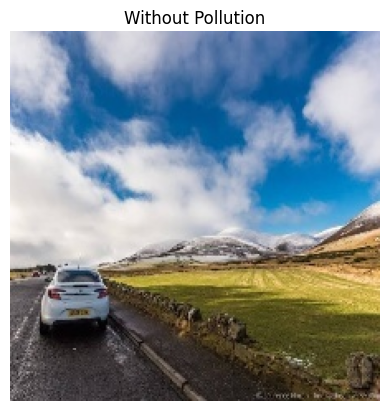

1/1 [==============================] - 0s 189ms/step
[[4.4198785e-12 1.0000000e+00]]
CLASS1
Predicted as Without Pollution


In [ ]:
### WITHOUT POLLUTION ###

image_path = '/content/drive/MyDrive/final_project/Dataset/test/selected_withoutPollution/NoPol_173.jpg'
image_plot = mpimg.imread(image_path)
plt.imshow(image_plot)
plt.title('Without Pollution')
plt.axis('off')
plt.show()
image = load_img(image_path, target_size=(224, 224))

image_array = img_to_array(image)
image_array = image_array / 255.0
image_array = np.expand_dims(image_array, axis=0)

predictions = model.predict(image_array)
predicted_class = np.argmax(predictions[0])
print(predictions)
print("CLASS" + str(predicted_class))
if predicted_class ==0:
    pre='Predicted as With Pollution'
else:
    pre='Predicted as Without Pollution'
print(pre)

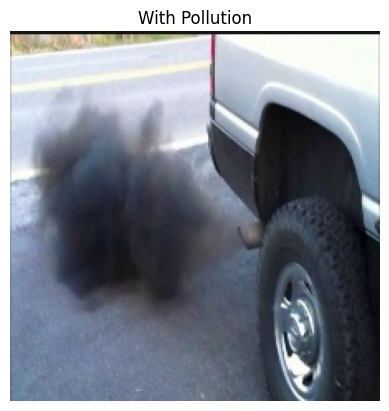

1/1 [==============================] - 0s 37ms/step
[[1.0000000e+00 3.4345343e-18]]
CLASS0
Predicted as With Pollution


In [ ]:
### WITH POLLUTION ###
image_path = '/content/drive/MyDrive/final_project/Dataset/test/selected_withPollution/Pol_132.jpg'
image = load_img(image_path, target_size=(224, 224))
image_plot = mpimg.imread(image_path)
plt.imshow(image_plot)
plt.title('With Pollution')
plt.axis('off')
plt.show()

image_array = img_to_array(image)
image_array = image_array / 255.0
image_array = np.expand_dims(image_array, axis=0)

predictions = model.predict(image_array)
predicted_class = np.argmax(predictions[0])
print(predictions)
print("CLASS" + str(predicted_class))
if predicted_class ==0:
    pre='Predicted as With Pollution'
else:
    pre='Predicted as Without Pollution'
print(pre)